In [1]:
!pip install -q -U unsloth
!pip install -q -U --no-deps trl peft accelerate bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.7/75.7 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.8/84.8 MB 22.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 MB 49.1 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 33.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 108.4 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.3 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 91.7 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.1 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 215.0/215.0 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 10.1 MB/s eta 0:00:00


In [2]:
import os
import json as _json
import random

import pandas as pd
import torch

from huggingface_hub import login

random.seed(42)

RAW_PAIRS_PATH = "/kaggle/input/datasets/amirsafarzadeh8203/raw-pairs-v10k-cleaned/raw_pairs_v10k_cleaned.csv"  # <-- این رو با مسیر واقعی عوض کن
LLM_BASE_MODEL = "unsloth/gemma-3-4b-it"
LLM_OUTPUT_DIR = "/kaggle/working/gemma3-fa-refinement-lora-v13"
LLM_REPO_ID = "amirsz8203/gemma3-fa-whisper-refinement-lora-v13"
SEED = 42
MAX_SEQ_LENGTH = 1024

try:
    from kaggle_secrets import UserSecretsClient
    HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
except Exception:
    HF_TOKEN = "خودتان جایگذاری کنید"

login(token=HF_TOKEN)

raw_pairs_df = pd.read_csv(RAW_PAIRS_PATH)
print("تعداد ردیف‌ها:", len(raw_pairs_df))
print(raw_pairs_df.columns.tolist())
raw_pairs_df.head()

تعداد ردیف‌ها: 9133
['path', 'sentence', 'raw_whisper']


,path,sentence,raw_whisper
0,/tmp/common_voice_fa_extracted/cv-corpus-26.0-...,بعد از بازی به مامان بابام گفتم بریم بیرون شلوغه,بعد از بازی به مامان بابام گفتم بریم بیرون شلوغه
1,/tmp/common_voice_fa_extracted/cv-corpus-26.0-...,اردیبهشت امسال خیلی جذاب بود,اردیوشت امسال خیلی جذاب بود
2,/tmp/common_voice_fa_extracted/cv-corpus-26.0-...,بیدقتی او به دشمنانش مستمسکی داد که بر ضد او ب...,بیدقتی او به دشمنانش مستمسکی داد که بر ضد او ب...
3,/tmp/common_voice_fa_extracted/cv-corpus-26.0-...,نان قهوه ای، لطفا.,نان قهوه ای، لطفا.
4,/tmp/common_voice_fa_extracted/cv-corpus-26.0-...,دوم اینکه نوع شواهد مهم است,دوم اینکه نوع شواهد مهم است


In [3]:
SYSTEM_PROMPT_FT = """متن زیر خروجی خام یک سیستم تشخیص گفتار (ASR) فارسیه.
وظیفه‌ی تو اصلاح نیم‌فاصله، علائم نگارشی، و تصحیح کلماتیه که به‌اشتباه توسط
سیستم تشخیص گفتار جایگزین شده‌اند (مثلاً به‌خاطر شباهت آوایی، مثل "گرمز" به‌جای "قرمز").

قوانین سخت‌گیرانه که هرگز نباید نقض بشن:
- تعداد کلمات نباید تغییر کند؛ فقط جایگزینیِ یک کلمه با کلمه‌ی دیگر مجاز است،
  نه حذف یا اضافه‌کردن کلمه.
- اگر مطمئن نیستی یک کلمه اشتباه است یا نه، همان‌طور که هست نگهش دار.
- اگر متن از قبل کاملاً درست است، دقیقاً همان را بدون هیچ تغییری برگردان.
- خروجی فقط باید خودِ متن نهایی باشد، بدون توضیح، بدون علامت نقل‌قول اضافه."""


import difflib

def word_similarity(raw, clean):
    raw_words = raw.split()
    clean_words = clean.split()
    matcher = difflib.SequenceMatcher(None, raw_words, clean_words)
    return matcher.ratio()  # بین 0 تا 1، هرچی بیشتر یعنی شبیه‌تر


def build_sft_examples(df, min_similarity=0.4):
    examples = []
    for _, row in df.iterrows():
        raw = str(row["raw_whisper"])
        clean = str(row["sentence"])
        if len(raw.split()) != len(clean.split()):
            continue
        sim = word_similarity(raw, clean)
        if sim < min_similarity:
            continue  
        examples.append({
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT_FT},
                {"role": "user", "content": raw},
                {"role": "assistant", "content": clean},
            ]
        })
    return examples


sft_examples = build_sft_examples(raw_pairs_df)
n_identical = sum(1 for ex in sft_examples if ex["messages"][1]["content"] == ex["messages"][2]["content"])
print(f"تعداد نمونه‌های مناسب: {len(sft_examples)} از {len(raw_pairs_df)}")
print(f"  بدون تغییر: {n_identical}  |  با تغییر: {len(sft_examples) - n_identical}")

DATASET_OUT_DIR = "/kaggle/working/llm_refinement_dataset"
os.makedirs(DATASET_OUT_DIR, exist_ok=True)
sft_path = os.path.join(DATASET_OUT_DIR, "sft_data.jsonl")
with open(sft_path, "w") as f:
    for ex in sft_examples:
        f.write(_json.dumps(ex, ensure_ascii=False) + "\n")
print("ذخیره شد:", sft_path)

تعداد نمونه‌های مناسب: 9133 از 9133
  بدون تغییر: 3587  |  با تغییر: 5546
ذخیره شد: /kaggle/working/llm_refinement_dataset/sft_data.jsonl


In [4]:
old_raw_pairs = pd.read_csv("/kaggle/input/datasets/amirsafarzadeh8203/raw-pairs-v280/raw_pairs_v280.csv")  # همون فایل قبلی (قبل از ترکیب)
combined_df = pd.read_csv("/kaggle/input/datasets/amirsafarzadeh8203/raw-pairs-v10k-cleaned/raw_pairs_v10k_cleaned.csv")  # یا مسیر Kaggle Dataset که آپلودش کردی

old_paths = set(old_raw_pairs["path"])
combined_df["source"] = combined_df["path"].apply(lambda p: "old" if p in old_paths else "new")

print(combined_df["source"].value_counts())

# حالا فیلتر شباهت رو دوباره اعمال کن و ببین رد شده‌ها از کدوم گروهن
import difflib

def word_similarity(raw, clean):
    matcher = difflib.SequenceMatcher(None, raw.split(), clean.split())
    return matcher.ratio()

combined_df["passed_wordcount"] = combined_df.apply(
    lambda r: len(str(r["raw_whisper"]).split()) == len(str(r["sentence"]).split()), axis=1
)
combined_df["similarity"] = combined_df.apply(
    lambda r: word_similarity(str(r["raw_whisper"]), str(r["sentence"])), axis=1
)
combined_df["passed_filter"] = combined_df["passed_wordcount"] & (combined_df["similarity"] >= 0.4)

print(combined_df.groupby("source")["passed_filter"].mean())  # نسبت قبولی هر گروه

source
new    4748
old    4385
Name: count, dtype: int64
source
new    1.0
old    1.0
Name: passed_filter, dtype: float64


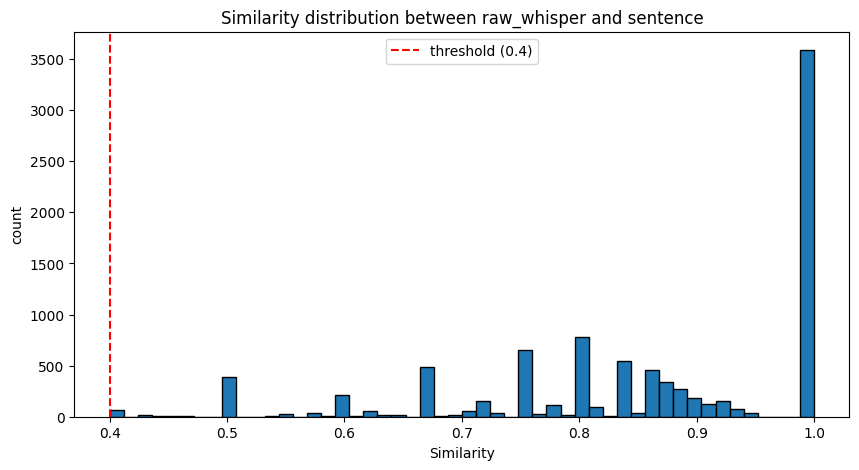

count    9133.000000
mean        0.857334
std         0.149840
min         0.400000
25%         0.769231
50%         0.875000
75%         1.000000
max         1.000000
Name: similarity, dtype: float64
sim_bucket
(0.0, 0.2]       0
(0.2, 0.3]       0
(0.3, 0.4]      70
(0.4, 0.5]     414
(0.5, 0.6]     293
(0.6, 0.7]     653
(0.7, 0.8]    1791
(0.8, 0.9]    1940
(0.9, 1.0]    3972
Name: count, dtype: int64


In [9]:
import matplotlib.pyplot as plt

# توزیع similarity برای کل دیتاست
plt.figure(figsize=(10, 5))
plt.hist(combined_df["similarity"], bins=50, edgecolor="black")
plt.axvline(0.4, color="red", linestyle="--", label="threshold (0.4)")
plt.xlabel("Similarity")
plt.ylabel("count")
plt.title("Similarity distribution between raw_whisper and sentence")
plt.legend()
plt.show()


print(combined_df["similarity"].describe())


bins = [0, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
combined_df["sim_bucket"] = pd.cut(combined_df["similarity"], bins=bins)
print(combined_df["sim_bucket"].value_counts().sort_index())

In [11]:
for lo, hi in [(0.4, 0.5), (0.5, 0.6)]:
    subset = combined_df[(combined_df["similarity"] >= lo) & (combined_df["similarity"] < hi)]
    print(f"\n=== بازه {lo}-{hi} (تعداد: {len(subset)}) ===")
    print(subset[["sentence", "raw_whisper", "similarity"]].sample(min(5, len(subset))))


=== بازه 0.4-0.5 (تعداد: 98) ===
                                      sentence  \
5776  ادامه بدهید از ایستگاه آتشنشانی رد شوید.   
1508      اصلن وقتی بیمار میشید چی کار میکنین؟   
3206                    می ترسیدم که شوکه بشین   
7468                نیاز است ودیعه پرداخت کنم؟   
3578                    می تونی راگبی بازی کنی   

                                raw_whisper  similarity  
5776  ادام بدهید عزیزگاه آتش نشانی رد شوید.    0.428571  
1508   اصلا وقتی بیمار میشید چیکار می کنید؟    0.428571  
3206                می توانید ام کشوکه بشین    0.400000  
7468                نیاز است وریع برقب کنم.    0.400000  
3578                 میتونی راگ بی بازی کنی    0.400000  

=== بازه 0.5-0.6 (تعداد: 464) ===
                    sentence             raw_whisper  similarity
3029  خب پس تو باهاش حرف زدی  خوب پس تو باش حرف زدیم         0.5
148       سپه، همان سپاه است      سپه همان سپاه است.         0.5
6656    هرکی شلوارش دوتا بشه    هرکی شلوارش تو تابشه         0.5
9094  واسه هردومون راح

In [13]:
from unsloth import FastModel

model, tokenizer = FastModel.from_pretrained(
    model_name=LLM_BASE_MODEL,
    max_seq_length=MAX_SEQ_LENGTH,
    load_in_4bit=True,
    full_finetuning=False,
)

model = FastModel.get_peft_model(
    model,
    r=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    random_state=SEED,
)
model.print_trainable_parameters()

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.8.18: Fast Gemma3 patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.562 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Unsloth: Using float16 precision for gemma3 won't work! Using float32.


Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

Unsloth: Dropout = 0 is supported for fast patching. You are using dropout = 0.05.
Unsloth will patch all other layers, except LoRA matrices, causing a performance hit.


trainable params: 32,788,480 || all params: 4,332,867,952 || trainable%: 0.7567


In [14]:
from unsloth.chat_templates import get_chat_template
from datasets import load_dataset

tokenizer = get_chat_template(tokenizer, chat_template="gemma3")


def format_example(example):
    text = tokenizer.apply_chat_template(example["messages"], tokenize=False, add_generation_prompt=False)
    return {"text": text}


sft_dataset = load_dataset("json", data_files=sft_path, split="train")
sft_dataset = sft_dataset.train_test_split(test_size=0.1, seed=SEED)

formatted_train = sft_dataset["train"].map(format_example, remove_columns=sft_dataset["train"].column_names)
formatted_eval = sft_dataset["test"].map(format_example, remove_columns=sft_dataset["test"].column_names)
print(sft_dataset)
print(formatted_train[0]["text"][:500])

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/8219 [00:00<?, ? examples/s]

Map:   0%|          | 0/914 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['messages'],
        num_rows: 8219
    })
    test: Dataset({
        features: ['messages'],
        num_rows: 914
    })
})
<bos><start_of_turn>user
متن زیر خروجی خام یک سیستم تشخیص گفتار (ASR) فارسیه.
وظیفه‌ی تو اصلاح نیم‌فاصله، علائم نگارشی، و تصحیح کلماتیه که به‌اشتباه توسط
سیستم تشخیص گفتار جایگزین شده‌اند (مثلاً به‌خاطر شباهت آوایی، مثل "گرمز" به‌جای "قرمز").

قوانین سخت‌گیرانه که هرگز نباید نقض بشن:
- تعداد کلمات نباید تغییر کند؛ فقط جایگزینیِ یک کلمه با کلمه‌ی دیگر مجاز است،
  نه حذف یا اضافه‌کردن کلمه.
- اگر مطمئن نیستی یک کلمه اشتباه است یا نه، همان‌طور که هست نگهش دار.
- اگر متن از قبل کاملاً درست است، دقیق


In [15]:
from trl import SFTTrainer, SFTConfig
from transformers import EarlyStoppingCallback

sft_config = SFTConfig(
    output_dir=LLM_OUTPUT_DIR,
    per_device_train_batch_size=2,       
    gradient_accumulation_steps=4,
    num_train_epochs=3,
    learning_rate=2e-4,
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    optim="adamw_8bit",
    weight_decay=0.01,
    lr_scheduler_type="linear",
    seed=SEED,
    report_to=["none"],
    max_length=MAX_SEQ_LENGTH,
    dataset_text_field="text",
)

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=formatted_train,
    eval_dataset=formatted_eval,
    processing_class=tokenizer,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=1)],
)

Unsloth: Switching to float32 training since model cannot work with float16
Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/8219 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/914 [00:00<?, ? examples/s]

In [16]:
trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 8,219 | Num Epochs = 3 | Total steps = 3,084
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 32,788,480 of 4,332,867,952 (0.76% trained)


Unsloth: Will smartly offload gradients to save VRAM!
Unsloth: Double buffering enabled (parallel H2D + compute) for backward pass.


Epoch,Training Loss,Validation Loss
1,0.275949,0.283276
2,0.250343,0.270032
3,0.226065,0.267531


Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma3-fa-refinement-lora-v13/checkpoint-1028/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /kaggle/working/gemma3-fa-refinement-lora-v13/checkpoint-1028.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma3-fa-refinement-lora-v13/checkpoint-2056/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /kaggle/working/gemma3-fa-refinement-lora-v13/checkpoint-2056.
Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma3-fa-refinement-lora-v13/checkpoint-3084/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /kaggle/working/gemma3-fa-refinement-lora-v13/checkpoint-3084.


TrainOutput(global_step=3084, training_loss=0.29369178284853503, metrics={'train_runtime': 14355.5786, 'train_samples_per_second': 1.718, 'train_steps_per_second': 0.215, 'total_flos': 1.3832737578991968e+17, 'train_loss': 0.29369178284853503, 'epoch': 3.0})

In [17]:
print(trainer.state.best_model_checkpoint)
print(trainer.state.best_metric)

/kaggle/working/gemma3-fa-refinement-lora-v13/checkpoint-3084
0.26753130555152893


In [18]:
import pandas as pd
pd.set_option("display.max_rows", None)

log_df = pd.DataFrame(trainer.state.log_history)
log_df = log_df[["step", "loss", "grad_norm", "learning_rate", "epoch"]].dropna(subset=["loss"]).reset_index(drop=True)

# پیدا کردن بزرگترین جهش‌ها در loss
log_df["loss_diff"] = log_df["loss"].diff()
print("\nبزرگترین جهش‌های loss:")
print(log_df.sort_values("loss_diff", ascending=False).head(10))

# پیدا کردن بزرگترین grad_norm ها
print("\nبزرگترین grad_norm ها:")
print(log_df.sort_values("grad_norm", ascending=False).head(10))


بزرگترین جهش‌های loss:
     step      loss  grad_norm  learning_rate     epoch  loss_diff
45    460  0.302993   1.112795       0.000189  0.447689   0.056692
85    860  0.338426   1.026087       0.000160  0.836983   0.054123
178  1790  0.287784   0.876727       0.000093  1.741606   0.050576
88    890  0.311984   0.865540       0.000158  0.866180   0.046827
38    390  0.319660   0.580313       0.000194  0.379562   0.045360
155  1560  0.270608   0.664567       0.000110  1.517762   0.041264
130  1310  0.290021   1.201990       0.000128  1.274453   0.040497
137  1380  0.276962   2.302125       0.000123  1.342579   0.039716
217  2180  0.257570   0.744735       0.000065  2.120681   0.038925
110  1110  0.287848   1.566283       0.000142  1.079805   0.037843

بزرگترین grad_norm ها:
     step      loss  grad_norm  learning_rate     epoch  loss_diff
0      10  3.578876   6.954063       0.000006  0.009732        NaN
266  2670  0.230366   5.358284       0.000030  2.597567  -0.016089
234  2350  0.2

In [20]:
save_dir = LLM_OUTPUT_DIR + "/final"
model.save_pretrained(save_dir)
tokenizer.save_pretrained(save_dir)
print("LoRA adapter ذخیره شد در:", save_dir)

model.push_to_hub(LLM_REPO_ID, token=HF_TOKEN)
tokenizer.push_to_hub(LLM_REPO_ID, token=HF_TOKEN)
print("push شد به:", LLM_REPO_ID)

Unsloth: Restored added_tokens_decoder metadata in /kaggle/working/gemma3-fa-refinement-lora-v13/final/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /kaggle/working/gemma3-fa-refinement-lora-v13/final.


LoRA adapter ذخیره شد در: /kaggle/working/gemma3-fa-refinement-lora-v13/final


README.md:   0%|          | 0.00/570 [00:00<?, ?B/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Saved model to https://huggingface.co/amirsz8203/gemma3-fa-whisper-refinement-lora-v13


Unsloth: Restored added_tokens_decoder metadata in /tmp/tmphyanpvqn/tokenizer_config.json.
Unsloth: Preserved sentencepiece asset `tokenizer.model` in /tmp/tmphyanpvqn.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

push شد به: amirsz8203/gemma3-fa-whisper-refinement-lora-v13


In [19]:
from unsloth import FastModel
FastModel.for_inference(model)

text_tokenizer = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

def punctuation_count(text):
    return sum(text.count(c) for c in "؟?!.")

def refine_text(raw_text):
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT_FT},
        {"role": "user", "content": raw_text},
    ]
    inputs = text_tokenizer.apply_chat_template(
        messages, tokenize=True, add_generation_prompt=True, return_tensors="pt"
    ).to(model.device)
    with torch.no_grad():
        out = model.generate(inputs, max_new_tokens=256, do_sample=False)
    result = text_tokenizer.decode(out[0][inputs.shape[1]:], skip_special_tokens=True).strip()

    raw_word_count = len(raw_text.split())
    refined_word_count = len(result.split())
    if refined_word_count != raw_word_count:
        print(f"  [هشدار] تعداد کلمات فرق کرد ({raw_word_count} -> {refined_word_count})؛ خروجی خام نگه داشته شد.")
        return raw_text
    if punctuation_count(result) < punctuation_count(raw_text):
        print("  [هشدار] علامت نگارشی حذف شده بود؛ خروجی خام نگه داشته شد.")
        return raw_text
    return result

test_samples = raw_pairs_df.sample(n=10, random_state=0).reset_index(drop=True)
for i, row in test_samples.iterrows():
    refined = refine_text(str(row["raw_whisper"]))
    print(f"--- نمونه {i + 1} ---")
    print("واقعی:      ", row["sentence"])
    print("خام Whisper:", row["raw_whisper"])
    print("بعد از LLM: ", refined)
    print()

The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


--- نمونه 1 ---
واقعی:       گفت حتما داشتم که صدا زدم؟
خام Whisper: گفت حدا داشتم که صدا زدم
بعد از LLM:  گفت حتما داشتم که صدا زدم

--- نمونه 2 ---
واقعی:       بيشتر تصويرگران و طراحان تبليغاتى
خام Whisper: بیشتر تصویرگران و طراحان تبلیغاتی
بعد از LLM:  بیشتر تصویرگران و طراحان تبلیغاتی

--- نمونه 3 ---
واقعی:       پیکانهای دردآور انتقاد
خام Whisper: پیگانهای دردآور انتقاد
بعد از LLM:  پیگانهای دردآور انتقاد

--- نمونه 4 ---
واقعی:       ایشالله که همه چیز درست بشه
خام Whisper: شالا که همه چیزی درست بشه
بعد از LLM:  شالا که همه چیز درست بشه

--- نمونه 5 ---
واقعی:       اولین قدم این است که با جزئیات اقرار کنید که چکار کرده اید
خام Whisper: اولین قدم این است که با جزیعیات اقرار کنید که چکار کرده اید
بعد از LLM:  اولین قدم این است که با جزییات اقرار کنید که چکار کرده اید.

--- نمونه 6 ---
واقعی:       امیرباقر
خام Whisper: امیرباقر
بعد از LLM:  امیرباقر

--- نمونه 7 ---
واقعی:       آیا قرمز را بیشتر از آبی دوست داری؟
خام Whisper: آیا قلمت را بیشتر از آبی دوست داری؟
بعد از LLM:  آیا

In [21]:
print(type(tokenizer))
print(hasattr(tokenizer, "tokenizer"))

<class 'transformers.models.gemma3.processing_gemma3.Gemma3Processor'>
True
